In [ ]:
!pip install kagglehub pandas matplotlib seaborn

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
path = kagglehub.dataset_download("atharvasoundankar/smart-farming-sensor-data-for-yield-prediction")

print("Path to dataset files:", path)

100%|██████████| 27.7k/27.7k [00:00<00:00, 11.4MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/atharvasoundankar/smart-farming-sensor-data-for-yield-prediction/versions/1


In [ ]:
import pandas as pd

df = pd.read_csv(path + "/Smart_Farming_Crop_Yield_2024.csv")

df.head()

,farm_id,region,crop_type,soil_moisture_%,soil_pH,temperature_C,rainfall_mm,humidity_%,sunlight_hours,irrigation_type,...,sowing_date,harvest_date,total_days,yield_kg_per_hectare,sensor_id,timestamp,latitude,longitude,NDVI_index,crop_disease_status
0,FARM0001,North India,Wheat,35.95,5.99,17.79,75.62,77.03,7.27,NaN,...,2024-01-08,2024-05-09,122,4408.07,SENS0001,2024-03-19,14.970941,82.997689,0.63,Mild
1,FARM0002,South USA,Soybean,19.74,7.24,30.18,89.91,61.13,5.67,Sprinkler,...,2024-02-04,2024-05-26,112,5389.98,SENS0002,2024-04-21,16.613022,70.869009,0.58,NaN
2,FARM0003,South USA,Wheat,29.32,7.16,27.37,265.43,68.87,8.23,Drip,...,2024-02-03,2024-06-26,144,2931.16,SENS0003,2024-02-28,19.503156,79.068206,0.80,Mild
3,FARM0004,Central USA,Maize,17.33,6.03,33.73,212.01,70.46,5.03,Sprinkler,...,2024-02-21,2024-07-04,134,4227.80,SENS0004,2024-05-14,31.071298,85.519998,0.44,NaN
4,FARM0005,Central USA,Cotton,19.37,5.92,33.86,269.09,55.73,7.93,NaN,...,2024-02-05,2024-05-20,105,4979.96,SENS0005,2024-04-13,16.568540,81.691720,0.84,Severe


In [ ]:
df.shape
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   farm_id               500 non-null    object 
 1   region                500 non-null    object 
 2   crop_type             500 non-null    object 
 3   soil_moisture_%       500 non-null    float64
 4   soil_pH               500 non-null    float64
 5   temperature_C         500 non-null    float64
 6   rainfall_mm           500 non-null    float64
 7   humidity_%            500 non-null    float64
 8   sunlight_hours        500 non-null    float64
 9   irrigation_type       350 non-null    object 
 10  fertilizer_type       500 non-null    object 
 11  pesticide_usage_ml    500 non-null    float64
 12  sowing_date           500 non-null    object 
 13  harvest_date          500 non-null    object 
 14  total_days            500 non-null    int64  
 15  yield_kg_per_hectare  5

Index(['farm_id', 'region', 'crop_type', 'soil_moisture_%', 'soil_pH',
       'temperature_C', 'rainfall_mm', 'humidity_%', 'sunlight_hours',
       'irrigation_type', 'fertilizer_type', 'pesticide_usage_ml',
       'sowing_date', 'harvest_date', 'total_days', 'yield_kg_per_hectare',
       'sensor_id', 'timestamp', 'latitude', 'longitude', 'NDVI_index',
       'crop_disease_status'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
farm_id,0
region,0
crop_type,0
soil_moisture_%,0
soil_pH,0
temperature_C,0
rainfall_mm,0
humidity_%,0
sunlight_hours,0
irrigation_type,150


In [ ]:
df["irrigation_type"] = df["irrigation_type"].fillna("Unknown")
df["crop_disease_status"] = df["crop_disease_status"].fillna("None")

In [ ]:
df.isnull().sum()

,0
farm_id,0
region,0
crop_type,0
soil_moisture_%,0
soil_pH,0
temperature_C,0
rainfall_mm,0
humidity_%,0
sunlight_hours,0
irrigation_type,0


In [ ]:
df["sowing_date"] = pd.to_datetime(df["sowing_date"])
df["harvest_date"] = pd.to_datetime(df["harvest_date"])
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   farm_id               500 non-null    object        
 1   region                500 non-null    object        
 2   crop_type             500 non-null    object        
 3   soil_moisture_%       500 non-null    float64       
 4   soil_pH               500 non-null    float64       
 5   temperature_C         500 non-null    float64       
 6   rainfall_mm           500 non-null    float64       
 7   humidity_%            500 non-null    float64       
 8   sunlight_hours        500 non-null    float64       
 9   irrigation_type       500 non-null    object        
 10  fertilizer_type       500 non-null    object        
 11  pesticide_usage_ml    500 non-null    float64       
 12  sowing_date           500 non-null    datetime64[ns]
 13  harvest_date        

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.groupby("crop_type")["yield_kg_per_hectare"].mean()
df.groupby("region")["yield_kg_per_hectare"].mean()
df.groupby("irrigation_type")["yield_kg_per_hectare"].mean()

,yield_kg_per_hectare
irrigation_type,
Drip,4019.453333
Manual,4070.093898
Sprinkler,4084.411901
Unknown,3972.128200


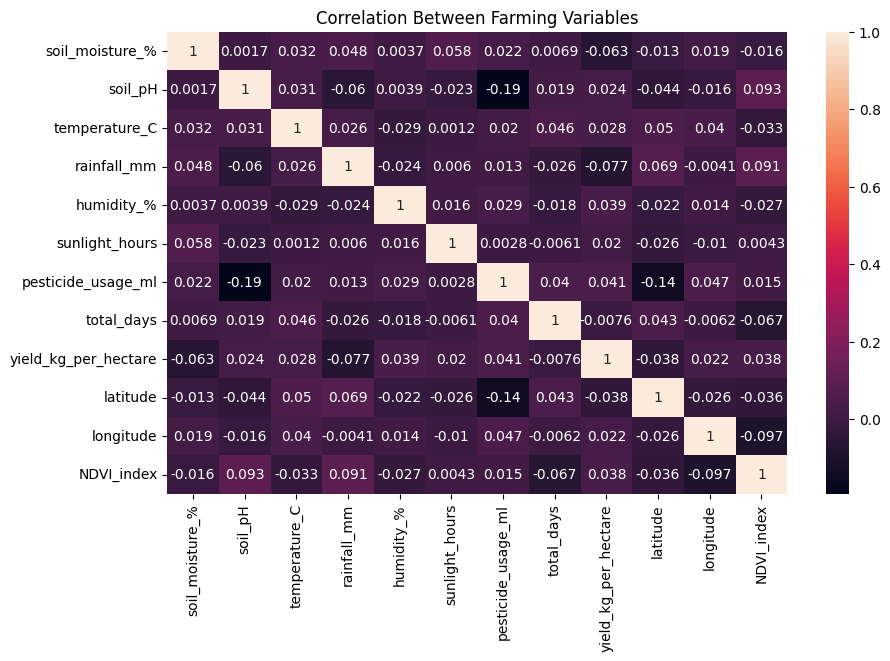

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)

plt.title("Correlation Between Farming Variables")
plt.show()

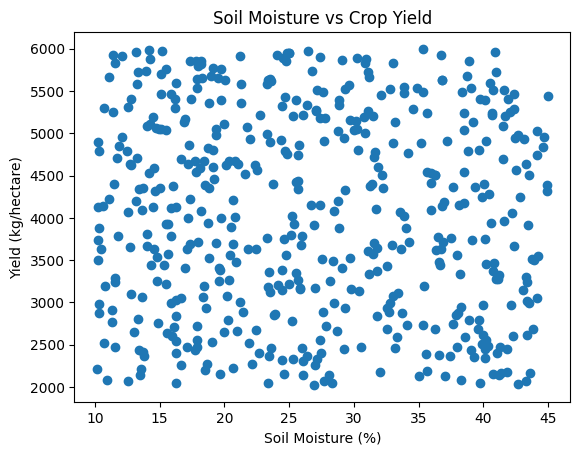

In [ ]:
plt.scatter(df["soil_moisture_%"], df["yield_kg_per_hectare"])

plt.xlabel("Soil Moisture (%)")
plt.ylabel("Yield (kg/hectare)")
plt.title("Soil Moisture vs Crop Yield")

plt.show()

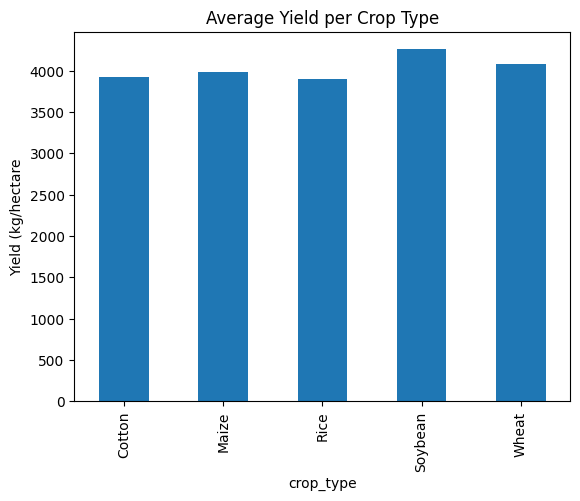

In [ ]:
df.groupby("crop_type")["yield_kg_per_hectare"].mean().plot(kind="bar")

plt.title("Average Yield per Crop Type")
plt.ylabel("Yield (kg/hectare")

plt.show()

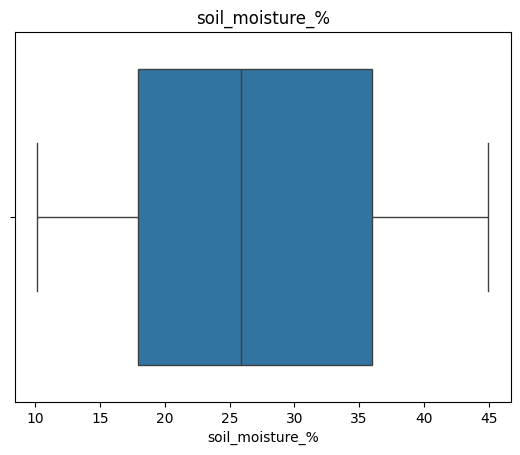

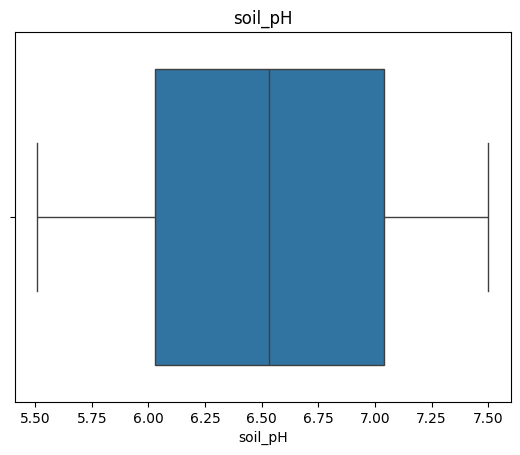

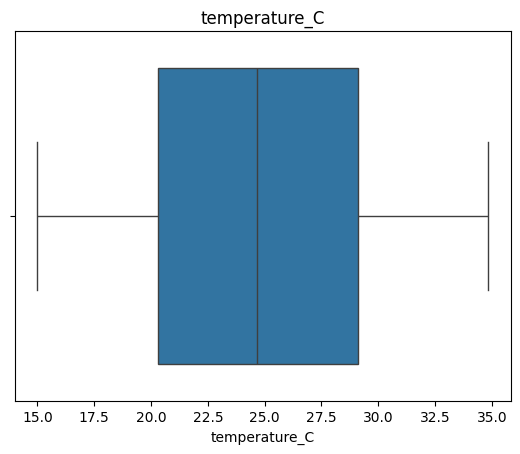

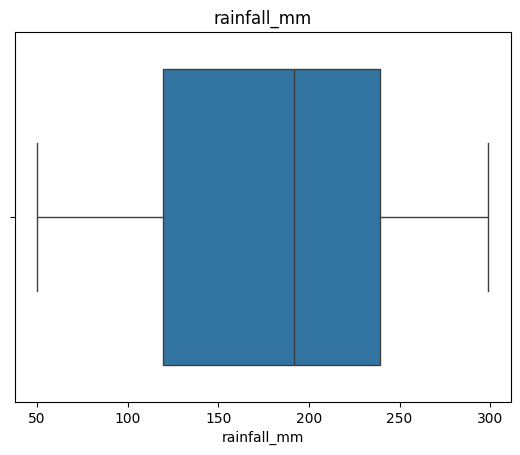

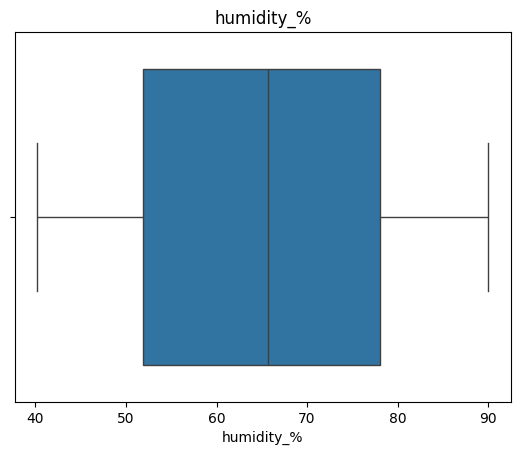

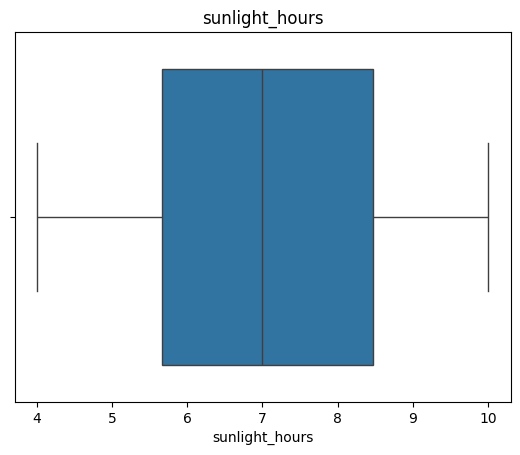

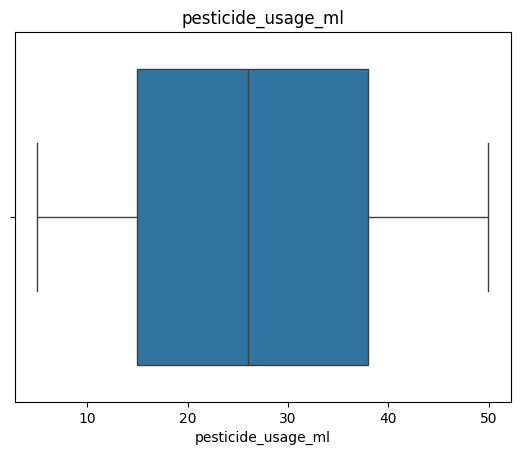

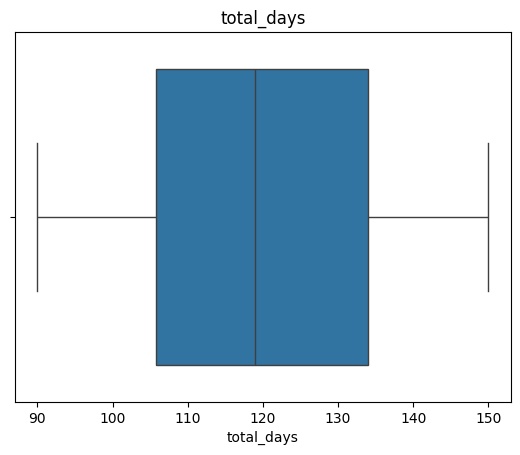

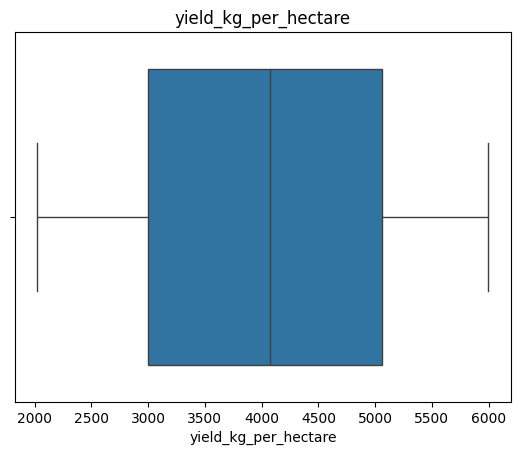

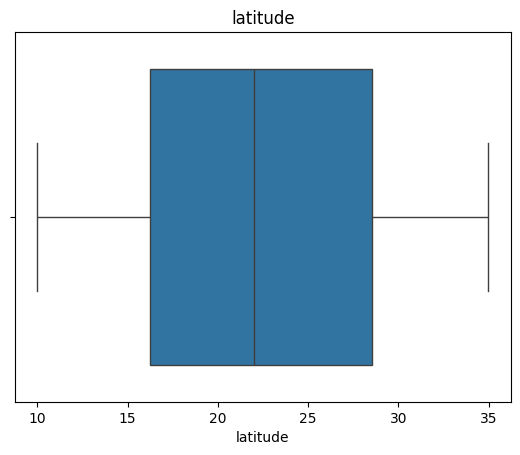

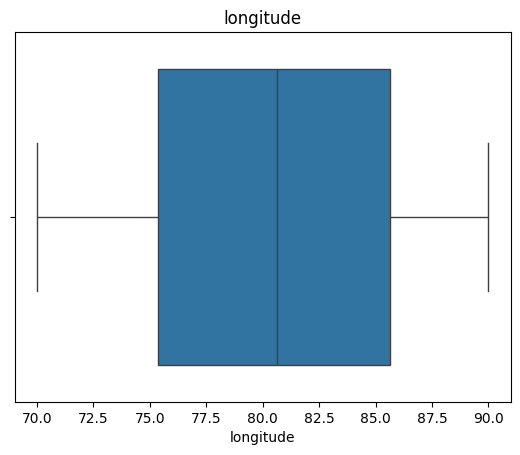

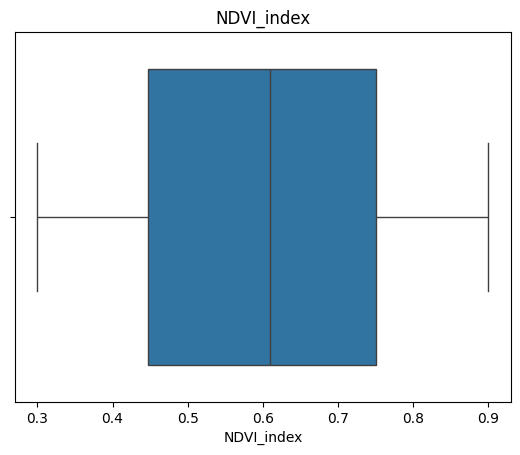

In [ ]:
numeric_cols = df.select_dtypes(include=['float64','int64']).columns

for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()


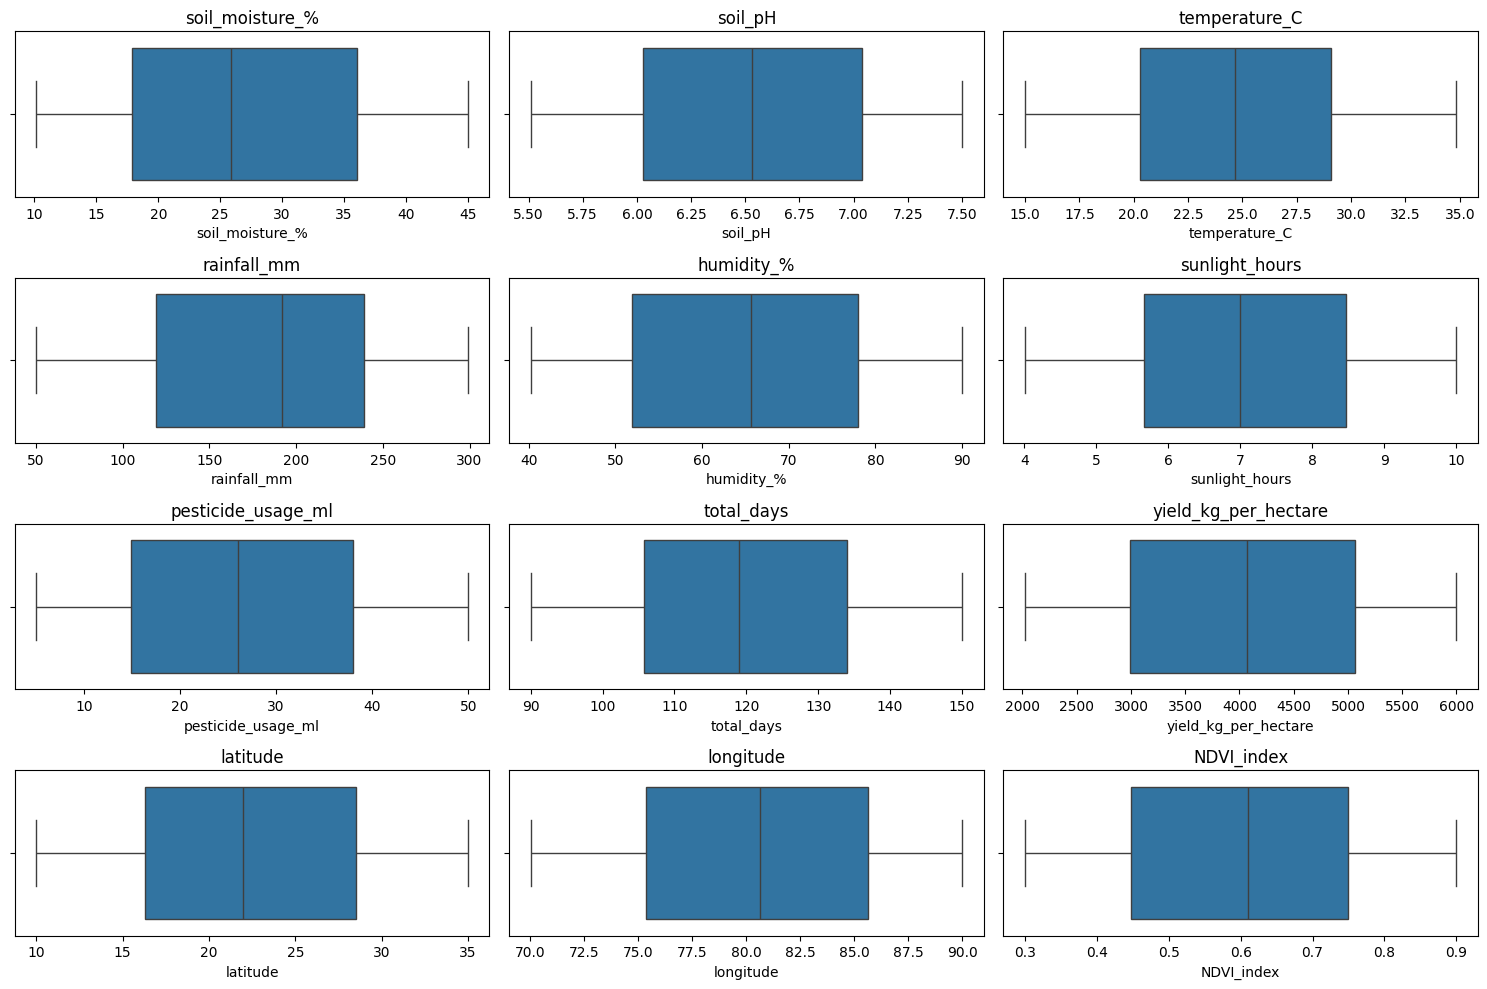

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include=['float64','int64']).columns

plt.figure(figsize=(15,10))

for i, col in enumerate(numeric_cols):
    plt.subplot(4,3,i+1)  # 4 baris 3 kolom
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

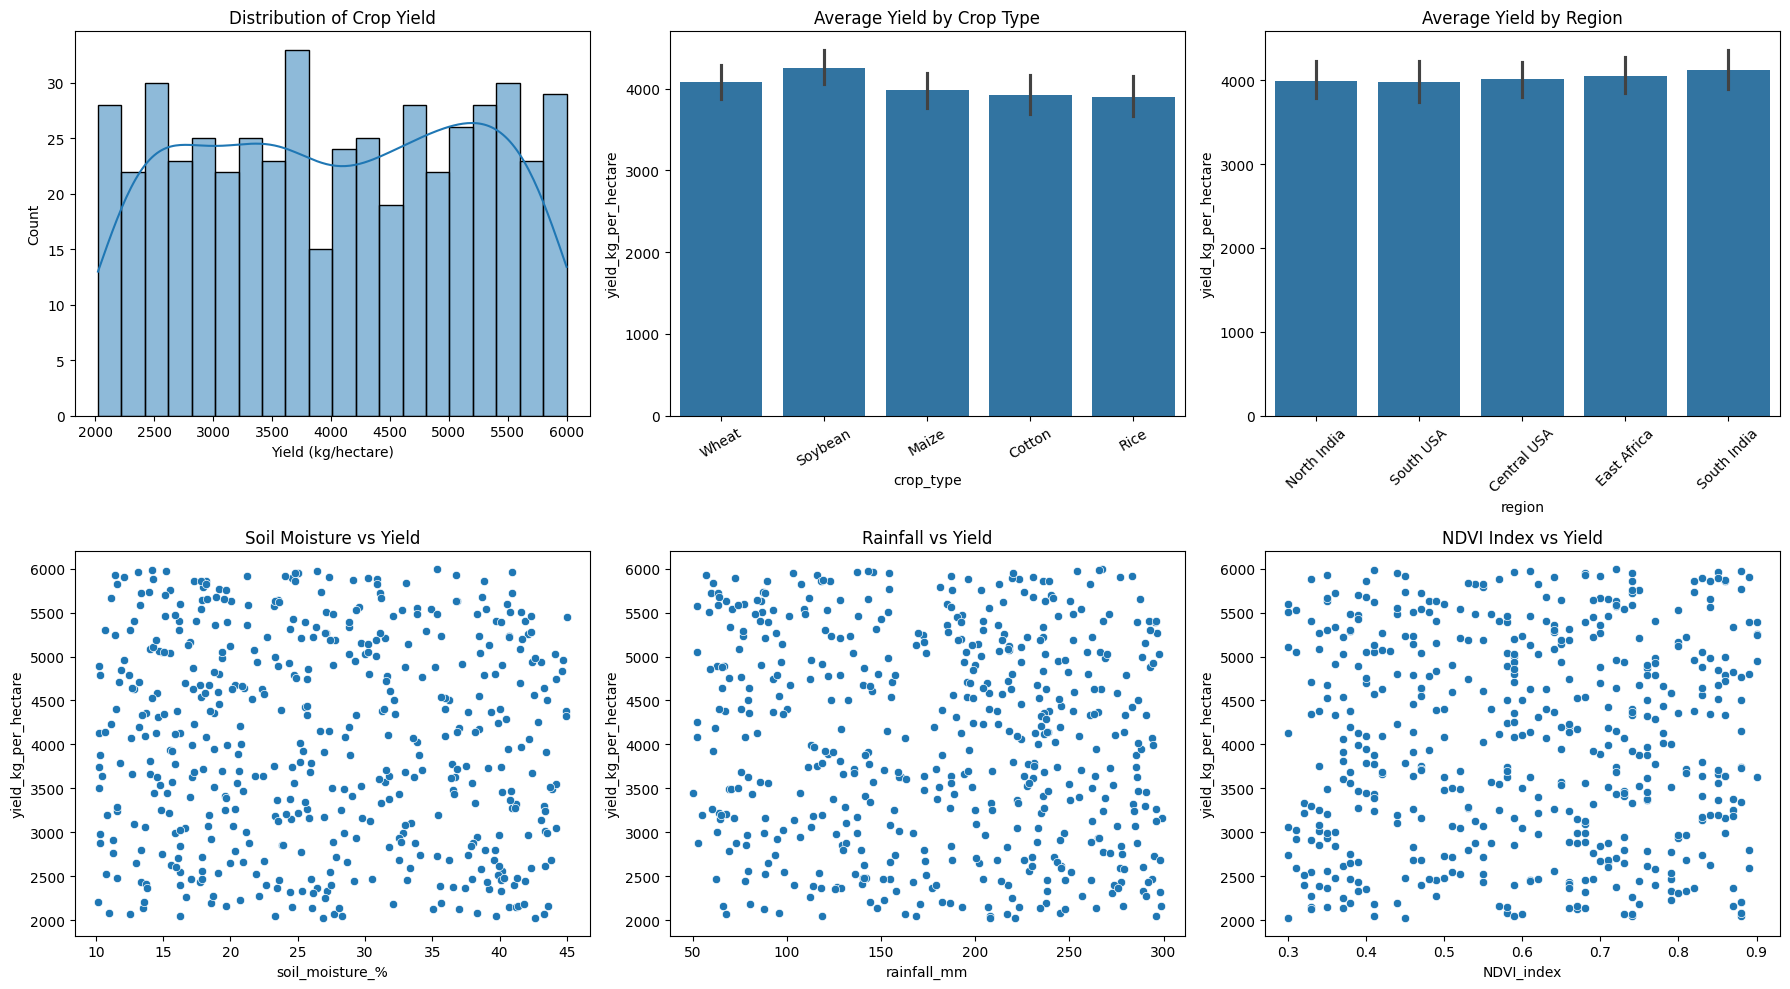

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18,10))

# 1 Yield Distribution
plt.subplot(2,3,1)
sns.histplot(df["yield_kg_per_hectare"], bins=20, kde=True)
plt.title("Distribution of Crop Yield")
plt.xlabel("Yield (kg/hectare)")

# 2 Yield by Crop Type
plt.subplot(2,3,2)
sns.barplot(x="crop_type", y="yield_kg_per_hectare", data=df)
plt.title("Average Yield by Crop Type")
plt.xticks(rotation=30)

# 3 Yield by Region
plt.subplot(2,3,3)
sns.barplot(x="region", y="yield_kg_per_hectare", data=df)
plt.title("Average Yield by Region")
plt.xticks(rotation=45)

# 4 Soil Moisture vs Yield
plt.subplot(2,3,4)
sns.scatterplot(x="soil_moisture_%", y="yield_kg_per_hectare", data=df)
plt.title("Soil Moisture vs Yield")

# 5 Rainfall vs Yield
plt.subplot(2,3,5)
sns.scatterplot(x="rainfall_mm", y="yield_kg_per_hectare", data=df)
plt.title("Rainfall vs Yield")

# 6 NDVI vs Yield
plt.subplot(2,3,6)
sns.scatterplot(x="NDVI_index", y="yield_kg_per_hectare", data=df)
plt.title("NDVI Index vs Yield")

plt.tight_layout()
plt.show()

/tmp/ipykernel_186/326241381.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_186/326241381.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_186/326241381.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_186/326241381.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


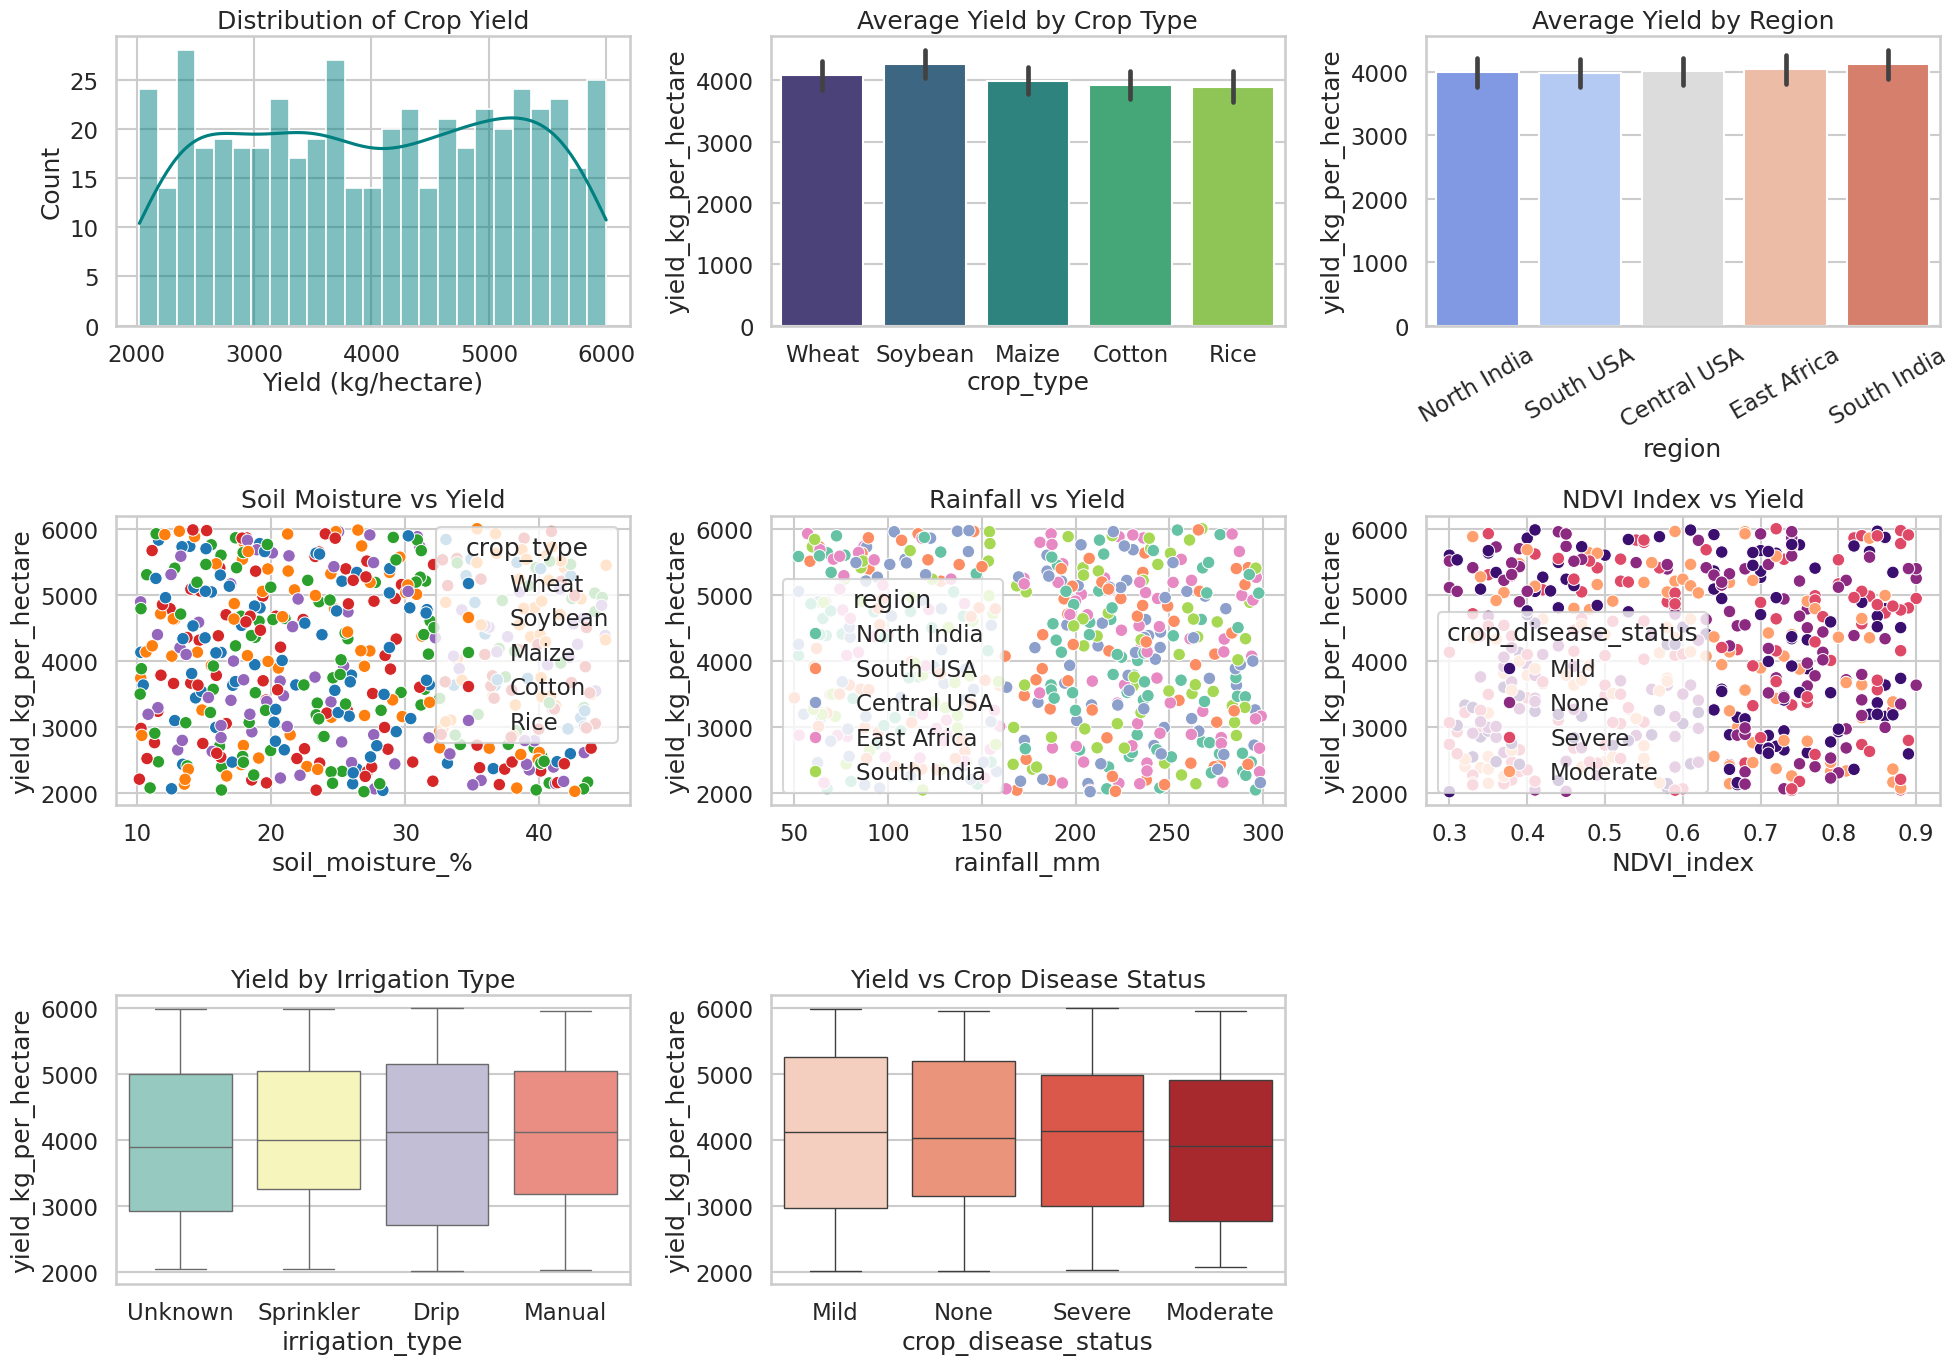

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_context("talk")

plt.figure(figsize=(20,14))

# 1 Distribution Yield
plt.subplot(3,3,1)
sns.histplot(df["yield_kg_per_hectare"], bins=25, kde=True, color="teal")
plt.title("Distribution of Crop Yield")
plt.xlabel("Yield (kg/hectare)")

# 2 Yield by Crop Type
plt.subplot(3,3,2)
sns.barplot(
    x="crop_type",
    y="yield_kg_per_hectare",
    data=df,
    palette="viridis"
)
plt.title("Average Yield by Crop Type")

# 3 Yield by Region
plt.subplot(3,3,3)
sns.barplot(
    x="region",
    y="yield_kg_per_hectare",
    data=df,
    palette="coolwarm"
)
plt.title("Average Yield by Region")
plt.xticks(rotation=30)

# 4 Soil Moisture vs Yield
plt.subplot(3,3,4)
sns.scatterplot(
    x="soil_moisture_%",
    y="yield_kg_per_hectare",
    hue="crop_type",
    palette="tab10",
    data=df
)
plt.title("Soil Moisture vs Yield")

# 5 Rainfall vs Yield
plt.subplot(3,3,5)
sns.scatterplot(
    x="rainfall_mm",
    y="yield_kg_per_hectare",
    hue="region",
    palette="Set2",
    data=df
)
plt.title("Rainfall vs Yield")

# 6 NDVI vs Yield
plt.subplot(3,3,6)
sns.scatterplot(
    x="NDVI_index",
    y="yield_kg_per_hectare",
    hue="crop_disease_status",
    palette="magma",
    data=df
)
plt.title("NDVI Index vs Yield")

# 7 Yield by Irrigation Type
plt.subplot(3,3,7)
sns.boxplot(
    x="irrigation_type",
    y="yield_kg_per_hectare",
    data=df,
    palette="Set3"
)
plt.title("Yield by Irrigation Type")

# 8 Yield by Disease Status
plt.subplot(3,3,8)
sns.boxplot(
    x="crop_disease_status",
    y="yield_kg_per_hectare",
    data=df,
    palette="Reds"
)
plt.title("Yield vs Crop Disease Status")

plt.tight_layout()
plt.show()

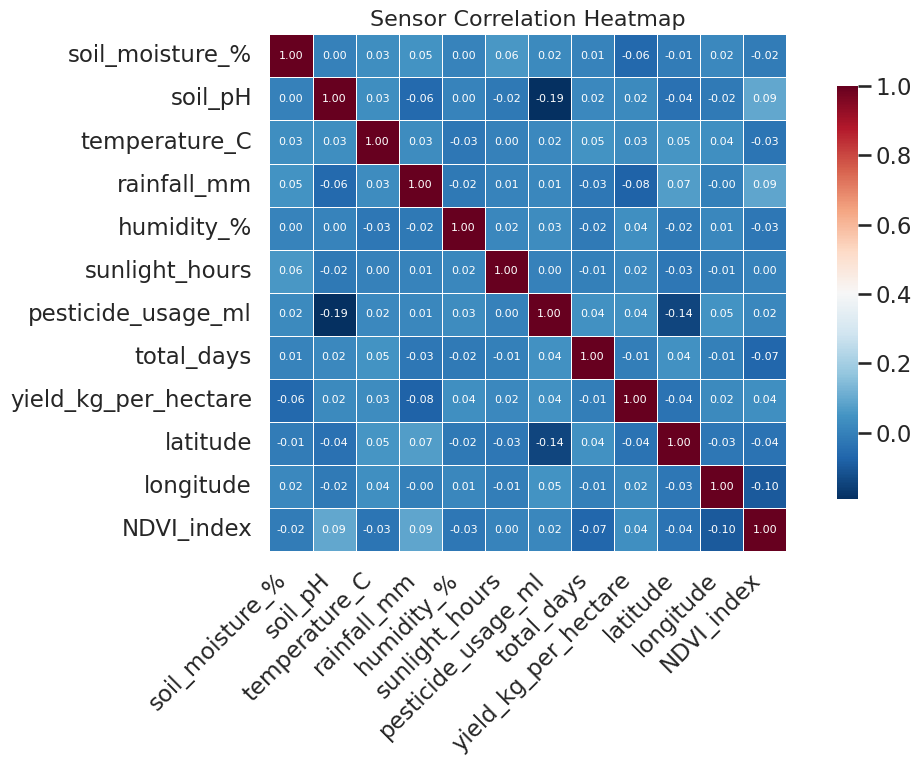

In [ ]:
plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="RdBu_r",
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": .8},
    annot_kws={"size":8}
)

plt.title("Sensor Correlation Heatmap", fontsize=16)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

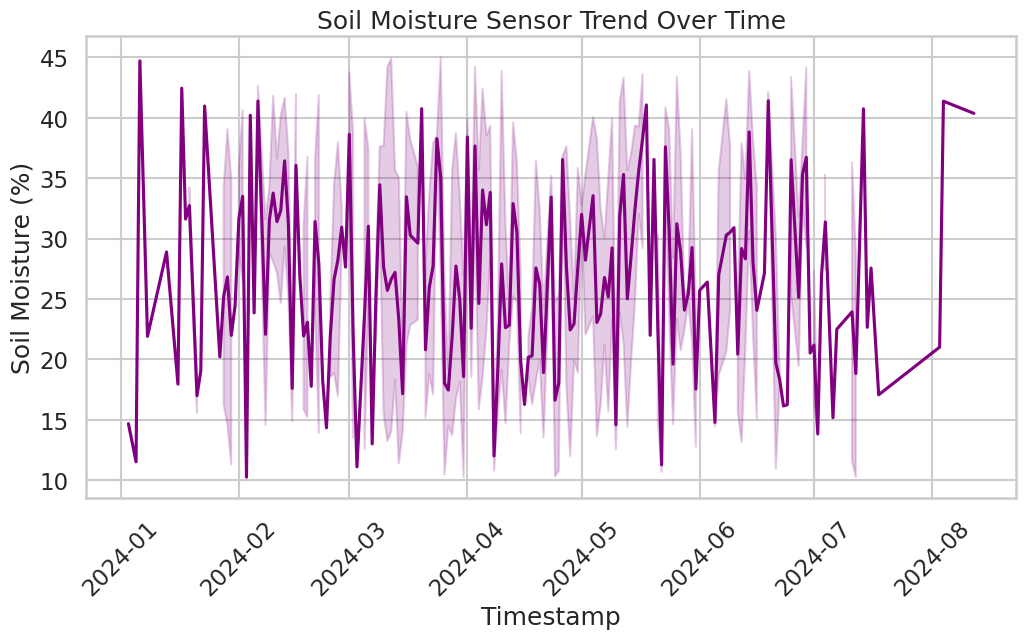

In [ ]:
plt.figure(figsize=(12,6))

df_sorted = df.sort_values("timestamp")

sns.lineplot(
    x="timestamp",
    y="soil_moisture_%",
    data=df_sorted,
    color="purple"
)

plt.title("Soil Moisture Sensor Trend Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Soil Moisture (%)")

plt.xticks(rotation=45)

plt.show()

In [ ]:
!pip install plotly

In [ ]:
import plotly.graph_objects as go

current_moisture = df["soil_moisture_%"].mean()

fig = go.Figure(go.Indicator(
    mode="gauge+number",
    value=current_moisture,
    title={'text': "Current Soil Moisture (%)"},

    gauge={
        'axis': {'range': [0, 50]},

        'steps': [
            {'range': [0, 20], 'color': "red"},
            {'range': [20, 35], 'color': "yellow"},
            {'range': [35, 50], 'color': "green"}
        ],

        'bar': {'color': "darkblue"}
    }
))

fig.show()

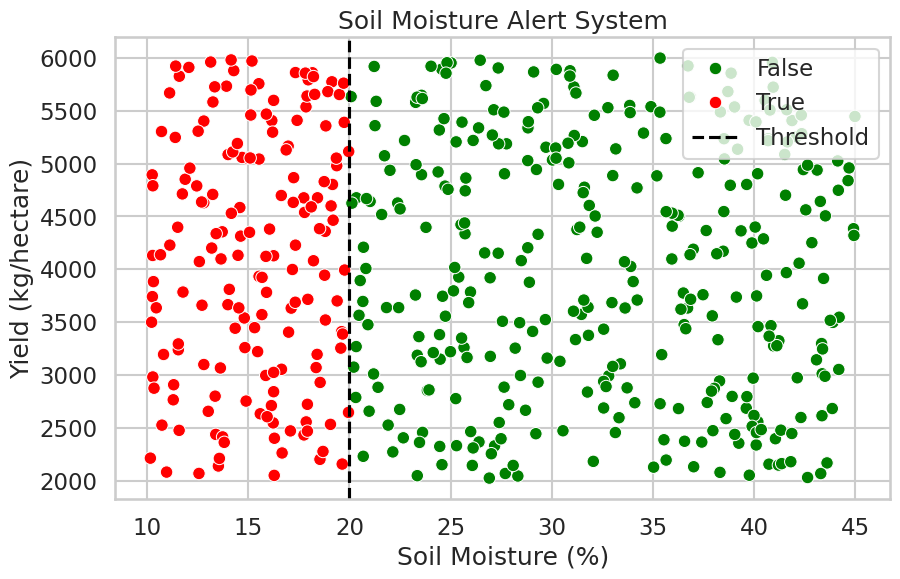

In [ ]:
threshold = 20

df["alert"] = df["soil_moisture_%"] < threshold

plt.figure(figsize=(10,6))

sns.scatterplot(
    x="soil_moisture_%",
    y="yield_kg_per_hectare",
    hue="alert",
    palette={True:"red", False:"green"},
    data=df
)

plt.axvline(threshold, color="black", linestyle="--", label="Threshold")

plt.title("Soil Moisture Alert System")
plt.xlabel("Soil Moisture (%)")
plt.ylabel("Yield (kg/hectare)")

plt.legend()

plt.show()